<a href="https://colab.research.google.com/github/Marconi-Lab/SolarIrradiation/blob/rm%2Frepo_navigation/notebooks/papers/mukiibi_mikelson_2026/ghi_bias_correction_reproducible.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GHI Bias Correction: A Machine Learning Approach
Run cells sequentially. The only prerequisites are:
- A valid BigQuery connection (configured in **§ 0**)
- The `susse` library installed in your environment



## § 0 — Imports and Configuration

In [1]:
import sys, os

if "google.colab" in sys.modules:
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"

    clone_url = f"https://github.com/{REPO}.git"
    if not os.path.exists("/content/Solar_irradiation/.git"):
        !git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation

%cd /content/Solar_irradiation
!pip install -q -e . 2>&1 | tail -3

from google.colab import auth
auth.authenticate_user()
!gcloud config set project solar-irradiation-estimation 2>/dev/null
print("Colab setup complete.")

/content/Solar_irradiation
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
Colab setup complete.


In [39]:
# ── Standard library ────────────────────────────────────────────────────────
import os, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Add the project root to sys.path to ensure 'susse' is found
_HERE = Path.cwd().resolve()
_PROJECT_ROOT = _HERE
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
_NB_DIR = _PROJECT_ROOT / "notebooks" / "papers" / "mukiibi_mikelson_2026"
sys.path.insert(0, str(_PROJECT_ROOT / "src"))
sys.path.insert(0, str(_NB_DIR))


# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── XGBoost ──────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── pvlib (for derived solar geometry feature) ───────────────────────────────
!pip install -q pvlib
import pvlib

# ── susse library ────────────────────────────────────────────────────────────
from susse.preprocessing import (
    AltitudeFeature, ClearSkyIndexFeature, CyclicalDayOfYearFeature,
    FeatureSpec, GhiUpperBoundCleaner, HighMissingYearExcluder,
    IqrLowerBoundCleaner, LongitudeFeature, Preprocessor,
    PvlibElevationProvider,
)

from susse.datasets import FeatureSelection
from susse.models import RandomForestParams
from susse.training import Trainer, TrainerConfig
from susse.warehouse_ops.population.types import IrradianceBand, Source

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
print("All imports successful.")


All imports successful.


In [3]:
# ── Output directories ───────────────────────────────────────────────────────
FIGURE_DIR = Path("./figures");  FIGURE_DIR.mkdir(exist_ok=True)
MODEL_DIR  = Path("./saved_models"); MODEL_DIR.mkdir(exist_ok=True)

# ── Matplotlib style (IEEE-compatible) ───────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          10,
    "axes.labelsize":     10,
    "axes.titlesize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "legend.framealpha":  0.8,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})
COLORS = {
    "measured":  "#1f77b4",
    "predicted": "#d62728",
    "nasa":      "#2ca02c",
    "cams":      "#ff7f0e",
}

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  ← review before every run
# ─────────────────────────────────────────────────────────────────────────────

# Holdout stations = paper's Sites A and B.
# UPDATE these once your supervisor confirms the site identities.
HOLDOUT_STATIONS: list[str] = ["wadelai", "kampala"]

# Random Forest hyperparameters (paper Section III)
RF_N_ESTIMATORS     = 200
RF_MIN_SAMPLES_LEAF = 5
RF_RANDOM_STATE     = 42

# Validation: paper uses 2021 only (monthly aggregation vs Katongole network)
VALIDATION_YEAR     = 2021

# Warehouse feature IDs ── NASA POWER aux variables (paper Table II)
NASA_AUX_IDS: tuple[str, ...] = (
    "longwave_downward_irr",      # CLRSKY_SFC_LW_DWN
    "aod_550_adj",                # AOD_55_ADJ
    "cloud_amount",               # CLOUD_AMT
    "precipitable_water",         # PW
    "airmass",                    # AIRMASS
    "zero_plane_displacement",    # DISPH
    "surface_albedo",             # SRF_ALB_ADJ
    "clearness_index",            # ALLSKY_KT
    "temperature",                # T2M
    "relative_humidity",          # RH2M
    "surface_pressure",           # PS
    "wind_speed",                 # WS2M
    "temperature_range",          # T2M_RANGE
    "precipitation_corrected",    # PRECTOTCORR
    "surface_roughness",          # Z0M
    "northern_wind",              # V2M
    "planetary_boundary",         # PBLTOP
    "total_column_ozone",         # TO3
    "surface_air_density",        # RHOA
    "surface_soil_wetness",       # GWETTOP
    "evaporation_land",           # EVLAND
    "evapotranspiration_energy",  # EVPTRNS
)
CAMS_AUX_IDS: tuple[str, ...] = ("ghi_clear", "dhi_clear", "dni_clear")


selection = FeatureSelection(
    nasa_variable_ids=NASA_AUX_IDS,
    cams_variable_ids=CAMS_AUX_IDS,
    include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    include_satellite_bands=(
        IrradianceBand.GHI, IrradianceBand.DHI, IrradianceBand.DNI,
    ),
    qc_levels=("pass",),
)

BUNDLE_DEST = MODEL_DIR / "rf_bundle"

LOG_TO_WANDB   = False          # set True to enable W&B experiment tracking
WANDB_PROJECT  = "ghi-bias-correction"
WANDB_ENTITY   = "your-entity"  # update if logging
WANDB_TAGS     = ["camera-ready", "reproduction"]

print("Configuration loaded.")
print(f"  Holdout stations : {HOLDOUT_STATIONS}")
print(f"  Validation year  : {VALIDATION_YEAR}")
print(f"  NASA aux features: {len(NASA_AUX_IDS)}")
print(f"  CAMS aux features: {len(CAMS_AUX_IDS)}")


Configuration loaded.
  Holdout stations : ['wadelai', 'kampala']
  Validation year  : 2021
  NASA aux features: 22
  CAMS aux features: 3


## § 1 — Data Loading

Pulls ground-measured GHI and all satellite/reanalysis predictor variables from the
BigQuery warehouse using the `susse` data-access layer.
The training corpus spans 24 sites across Sub-Saharan Africa (Table I in the paper).


In [22]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs
from susse.datasets import FeatureService, DatasetManifest, TrainingDataset
from susse.provenance import git_sha, susse_version

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)
service = FeatureService(bq=bq)

station_meta = bq.query(f"""
    SELECT location,
           ANY_VALUE(lat) AS lat,
           ANY_VALUE(lon) AS lon,
           MIN(date) AS min_date,
           MAX(date) AS max_date,
           COUNT(*)  AS n_rows
    FROM `{tables.ground_measurements}`
    WHERE qc_level = "pass"
    GROUP BY location
    ORDER BY n_rows DESC
""")

# ----- Explicit holdout: Wadelai + Kampala -----
# Both stations are pinned rather than picked algorithmically, so the
# split is identical to the paper's intended experiment.
N_TRAINING_STATIONS  = 22
N_HOLDOUT_STATIONS   = 2
HOLDOUT_STATION_NAMES = ["wadelai", "kampala"]  # pinned — not picked algorithmically

for _name in HOLDOUT_STATION_NAMES:
    assert _name in station_meta["location"].values, (
        f"Holdout station '{_name}' not found in the warehouse.\n"
        f"Available: {list(station_meta['location'])}"
    )

HOLDOUT_STATIONS = HOLDOUT_STATION_NAMES

# Training pool: top stations by row count, excluding both holdout stations.
# Taking the N_TRAINING_STATIONS highest-coverage non-holdout stations
# gives 24 total stations, consistent with the paper.
_candidates = station_meta.loc[
    ~station_meta["location"].isin(HOLDOUT_STATIONS), "location"
].tolist()
TRAINING_STATIONS = _candidates[:N_TRAINING_STATIONS]

selected_stations = TRAINING_STATIONS + HOLDOUT_STATIONS
print(f"Training stations ({len(TRAINING_STATIONS)}): {TRAINING_STATIONS}")
print(f"Holdout stations  ({len(HOLDOUT_STATIONS)}) : {HOLDOUT_STATIONS}")
print(f"Total             ({len(selected_stations)})")

KATONGOLE_CSV = (
    _PROJECT_ROOT / "data" / "external_references" / "katongole_2023_monthly.csv"
)
assert KATONGOLE_CSV.exists(), f"Missing reference data at {KATONGOLE_CSV}"

Training stations (22): ['kenya_location3', 'lira', 'ghana_location1', 'nigeria_location1', 'kenya_location5', 'tororo', 'ghana_location3', 'ghana_location2', 'kenya_location2', 'kenya_location6', 'kenya_location4', 'soroti', 'kenya_location13', 'kenya_location8', 'kenya_location10', 'nigeria_location2', 'madagascar_location1', 'kenya_location7', 'kenya_location11', 'egypt_location1', 'madagascar_location2', 'kenya_location14']
Holdout stations  (2) : ['wadelai', 'kampala']
Total             (24)


In [5]:
# Pull ground + satellite features for the 24 selected stations across
# their full ground-data range. Cleaners in §3 then filter rows.
DATE_START = station_meta.loc[
    station_meta["location"].isin(selected_stations), "min_date"
].min()
DATE_END = station_meta.loc[
    station_meta["location"].isin(selected_stations), "max_date"
].max()
raw_df = service.build_training_pairs(
    selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    locations=selected_stations,
)
manifest = DatasetManifest(
    name="mukiibi_mikelson_2026_train",
    version="recomputation_v1",
    created_at_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    susse_version=susse_version(),
    git_sha=git_sha(),
    feature_selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    location_filter=None,
    warehouse_project=bq.config.project_id,
    warehouse_dataset=bq.config.dataset,
    warehouse_table_mods=service.warehouse_table_mods(selection),
    n_rows=len(raw_df),
    n_cols=len(raw_df.columns),
    column_names=tuple(raw_df.columns),
    content_hash="recomputation",
)
dataset = TrainingDataset(df=raw_df, manifest=manifest)
print(f"Raw training pairs: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Date span: {DATE_START} .. {DATE_END}")
print(f"Stations: {raw_df['location'].nunique()}")

Raw training pairs: 24,233 rows × 38 columns
Date span: 2011-03-08 .. 2024-11-25
Stations: 24


## § 2 — Preprocessing

Applies the data-curation pipeline described in paper Section II.A:
- **Upper-bound cleaning**: removes physically impossible GHI values (> 12 kWh m⁻² d⁻¹)
- **IQR lower-bound filtering**: removes anomalously low values
- **High-missing-year exclusion**: drops station-years with > 5 % missing data
- **k-NN imputation** of remaining small gaps (handled internally by `Preprocessor`)
- **Derived features**: clear-sky index, cyclical day-of-year, raw day-of-year integer,
  site altitude, longitude, and solar noon zenith angle (via pvlib)


In [6]:
# ── FeatureSpec ───────────────────────────────────────────────────────────────
feature_columns = (
    *(f"nasa_{v}" for v in NASA_AUX_IDS),
    *(f"cams_{v}" for v in CAMS_AUX_IDS),
    *(
        f"sat_{band.value}_{source.value.lower()}_kwh_m2_day"
        for band in selection.include_satellite_bands
        for source in selection.include_satellite_irradiance
    ),
)
spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=feature_columns,
    cleaners=(
        GhiUpperBoundCleaner(column="y_ghi_kwh_m2_day", threshold=12.0),
        IqrLowerBoundCleaner(column="y_ghi_kwh_m2_day", multiplier=1.5),
        HighMissingYearExcluder(missing_fraction_threshold=0.05),
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
        AltitudeFeature(provider=PvlibElevationProvider()),
        LongitudeFeature(),
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)

# ── Run preprocessing ─────────────────────────────────────────────────────────
preprocessor = Preprocessor(spec=spec)
processed    = preprocessor.apply(dataset)

n_features = len(processed.feature_columns)
n_rows     = len(processed.df)
print(f"Preprocessed dataset: {n_rows:,} rows  ×  {n_features} features")
print(f"Feature columns ({n_features}):")
for i, col in enumerate(processed.feature_columns, 1):
    print(f"  {i:2d}. {col}")


Preprocessed dataset: 15,523 rows  ×  36 features
Feature columns (36):
   1. nasa_longwave_downward_irr
   2. nasa_aod_550_adj
   3. nasa_cloud_amount
   4. nasa_precipitable_water
   5. nasa_airmass
   6. nasa_zero_plane_displacement
   7. nasa_surface_albedo
   8. nasa_clearness_index
   9. nasa_temperature
  10. nasa_relative_humidity
  11. nasa_surface_pressure
  12. nasa_wind_speed
  13. nasa_temperature_range
  14. nasa_precipitation_corrected
  15. nasa_surface_roughness
  16. nasa_northern_wind
  17. nasa_planetary_boundary
  18. nasa_total_column_ozone
  19. nasa_surface_air_density
  20. nasa_surface_soil_wetness
  21. nasa_evaporation_land
  22. nasa_evapotranspiration_energy
  23. cams_ghi_clear
  24. cams_dhi_clear
  25. cams_dni_clear
  26. sat_ghi_nasa_kwh_m2_day
  27. sat_ghi_cams_kwh_m2_day
  28. sat_dhi_nasa_kwh_m2_day
  29. sat_dhi_cams_kwh_m2_day
  30. sat_dni_nasa_kwh_m2_day
  31. sat_dni_cams_kwh_m2_day
  32. kt_cams
  33. doy_sin
  34. doy_cos
  35. altitude_m
 

### Data exploration

Four quick views of the training data: target distribution per station,
satellite-vs-observed scatter, feature-correlation heatmap, and a PCA
scatter coloured by station. All four are plot-only — implementations
live in `auxscripts`.

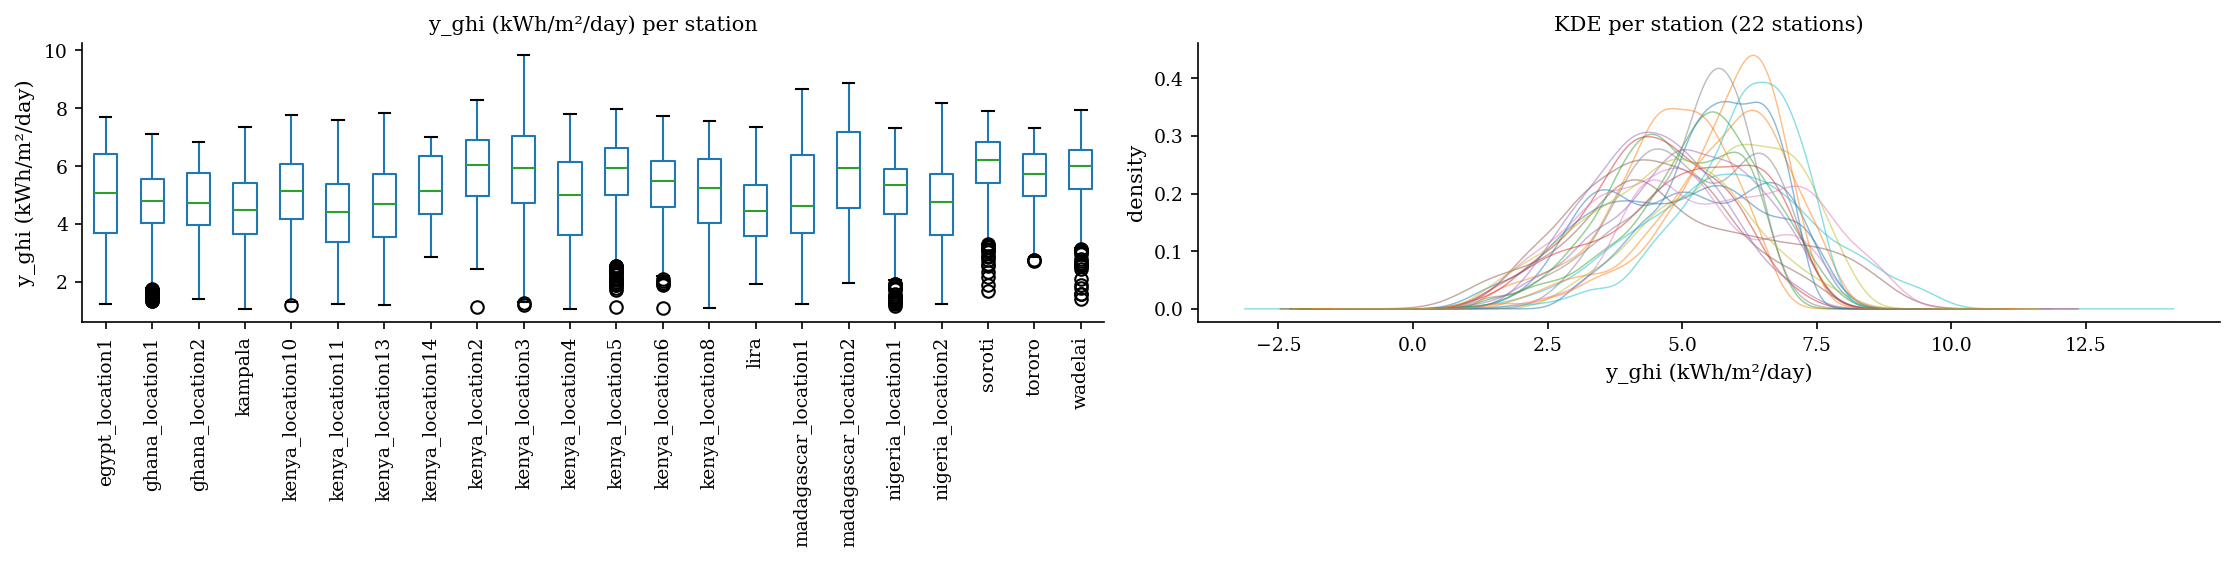

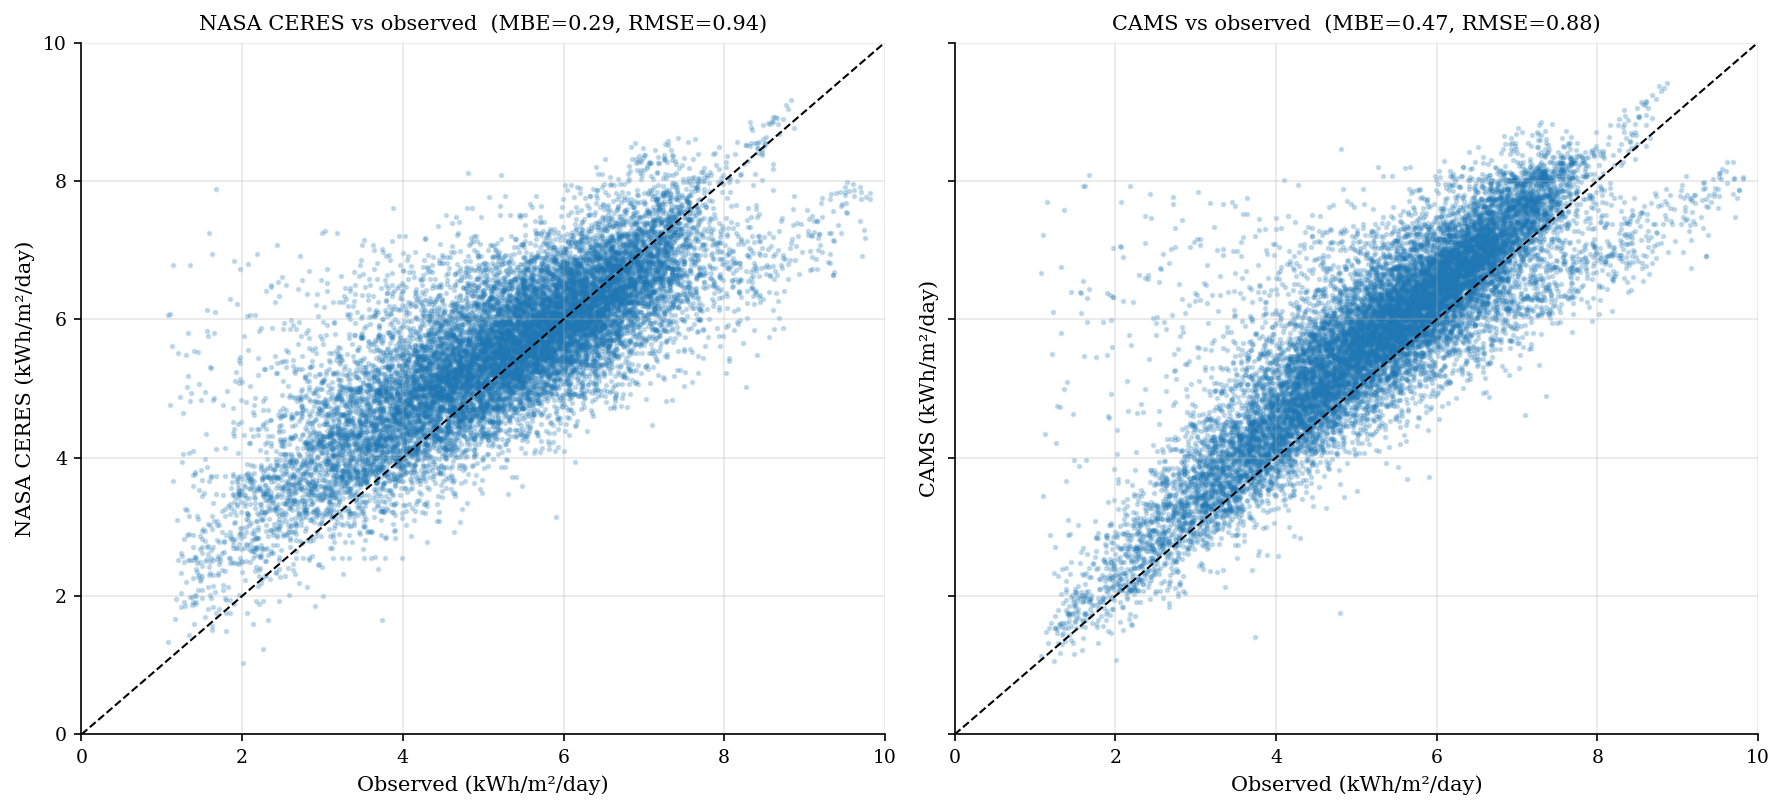

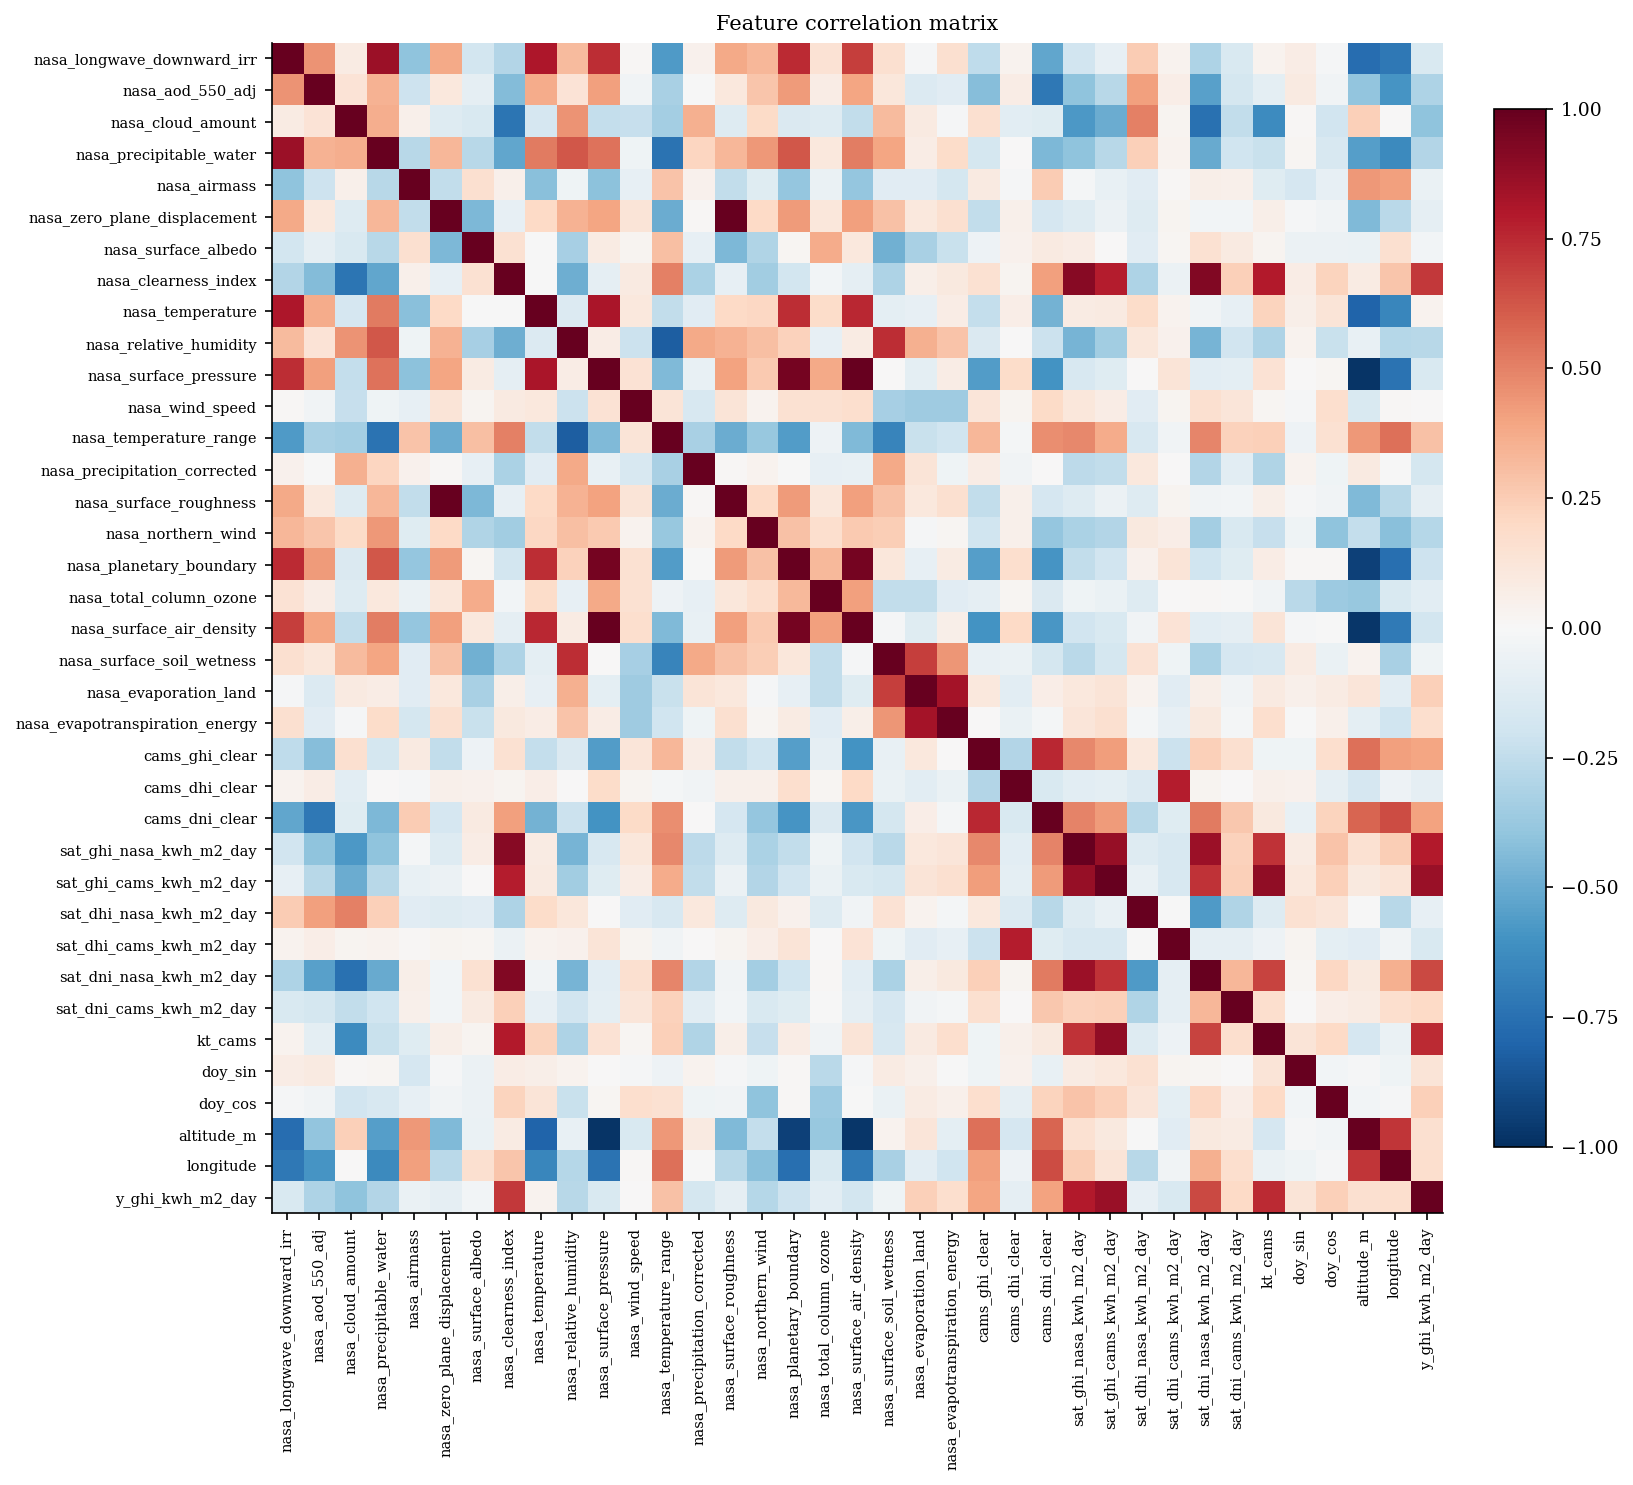

Top 10 features by |correlation| with y_ghi_kwh_m2_day:
sat_ghi_cams_kwh_m2_day   0.8650
sat_ghi_nasa_kwh_m2_day   0.7900
kt_cams                   0.7500
nasa_clearness_index      0.7110
sat_dni_nasa_kwh_m2_day   0.6630
cams_dni_clear            0.4020
nasa_cloud_amount         0.4000
cams_ghi_clear            0.3940
nasa_aod_550_adj          0.3070
nasa_temperature_range    0.2930


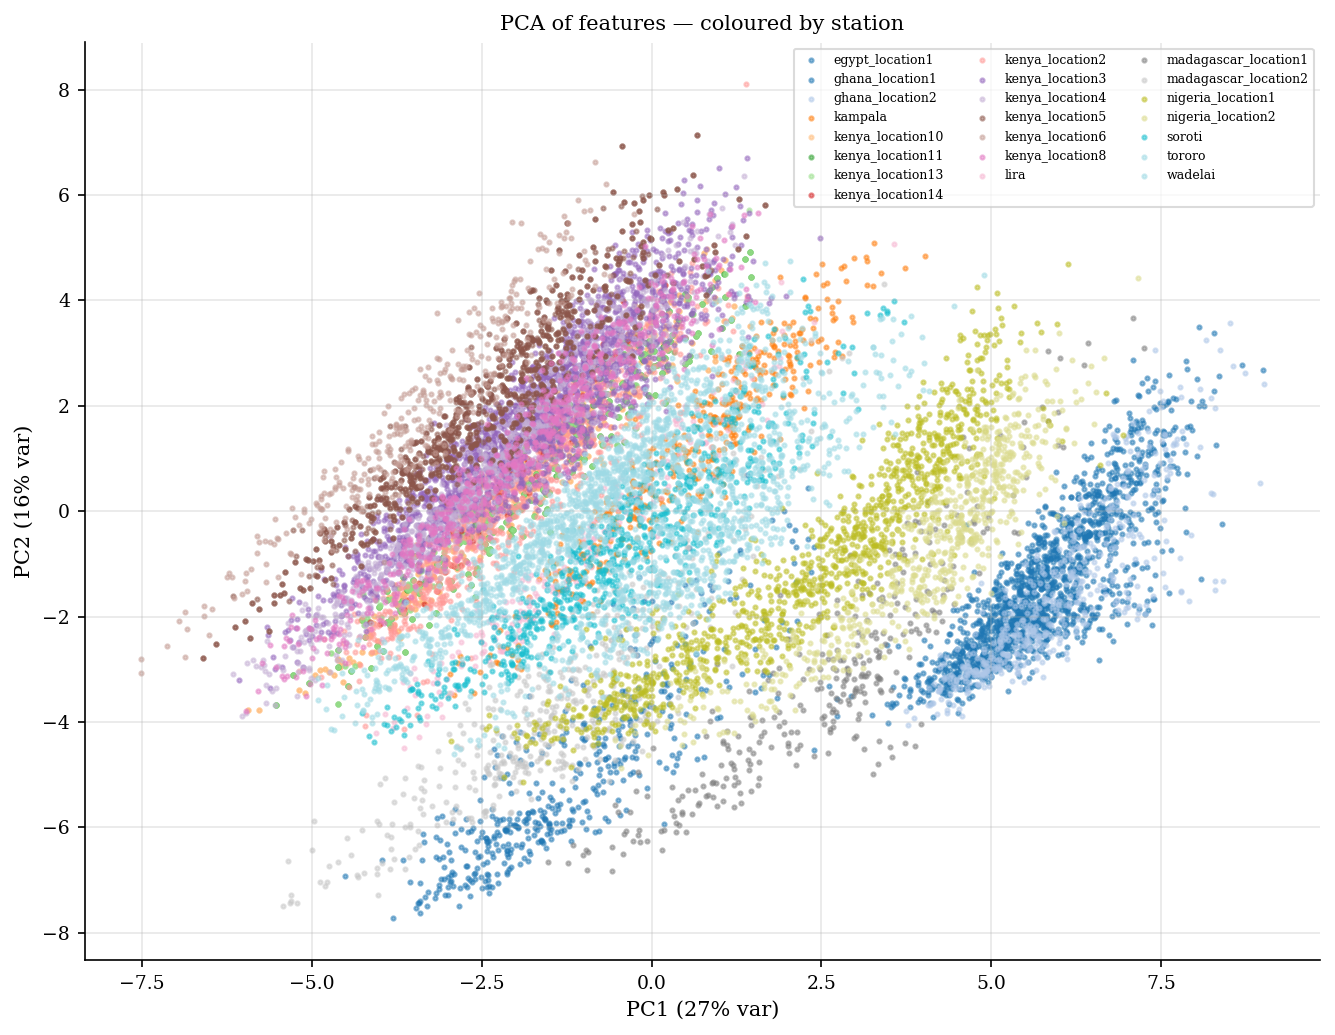

In [7]:
from susse.evaluation.plots import (
    plot_feature_correlation_heatmap,
    plot_pca_by_station,
    plot_predictor_vs_observed_scatter,
    plot_target_distribution_per_station,
)

plot_target_distribution_per_station(
    processed.df,
    target_column=spec.target_column,
    value_label="y_ghi (kWh/m²/day)",
)
plot_predictor_vs_observed_scatter(
    processed.df,
    observed_column=spec.target_column,
    predictor_columns={
        "NASA CERES": "sat_ghi_nasa_kwh_m2_day",
        "CAMS":       "sat_ghi_cams_kwh_m2_day",
    },
)
plot_feature_correlation_heatmap(
    processed.df,
    feature_columns=processed.feature_columns,
    target_column=spec.target_column,
)
plot_pca_by_station(
    processed.df, feature_columns=processed.feature_columns,
)

## § 3 — Training / Holdout Split

Spatial holdout: the two Ministry stations (Sites A and B) are withheld entirely
from training. All remaining stations form the training set.
This mirrors the 80/20 split described in paper Section III.


In [8]:
from susse.training import SpatialBlockSplitter

splitter = SpatialBlockSplitter(
    val_blocks=HOLDOUT_STATIONS,
    block_column="location",
)
train_idx, val_idx = splitter.split(processed)

TRAINING_STATIONS = [
    s for s in processed.df["location"].unique() if s not in HOLDOUT_STATIONS
]

X = processed.X().values
y = processed.df[spec.target_column].values

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

print(f"Training stations  : {len(TRAINING_STATIONS)}")
print(f"Training rows      : {len(train_idx):,}")
print(f"Holdout stations   : {HOLDOUT_STATIONS}")
print(f"Holdout rows       : {len(val_idx):,}")
print()
print(f"Target — training  : mean={y_train.mean():.3f}, std={y_train.std():.3f} kWh m⁻² d⁻¹")
print(f"Target — holdout   : mean={y_val.mean():.3f},   std={y_val.std():.3f} kWh m⁻² d⁻¹")


Training stations  : 20
Training rows      : 14,403
Holdout stations   : ['wadelai', 'kampala']
Holdout rows       : 1,120

Target — training  : mean=5.257, std=1.465 kWh m⁻² d⁻¹
Target — holdout   : mean=5.266,   std=1.305 kWh m⁻² d⁻¹


## § 4 — Daily-Scale Model Comparison (Paper Table III)

All five candidate models are trained on the same 22-station training split and
evaluated on the held-out stations. This section produces **Table III** of the paper.

SVR is wrapped in a `Pipeline` with `StandardScaler` — the only model that requires
feature scaling. All other models are scale-invariant.


In [11]:
# ── Metric helpers ───────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mbe(y_true, y_pred):
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))

def index_of_agreement(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    obs_mean = y_true.mean()
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((np.abs(y_pred - obs_mean) + np.abs(y_true - obs_mean)) ** 2)
    return float(1 - num / den)

def compute_all_metrics(y_true, y_pred, label=""):
    r = rmse(y_true, y_pred)
    m = mean_absolute_error(y_true, y_pred)
    obs_mean = float(np.mean(y_true))
    return {
        "label":  label,
        "RMSE":   r,
        "nRMSE":  r / obs_mean * 100,
        "MAE":    m,
        "nMAE":   m / obs_mean * 100,
        "MBE":    mbe(y_true, y_pred),
        "R2":     float(r2_score(y_true, y_pred)),
        "IOA":    index_of_agreement(y_true, y_pred),
    }


# ── Candidate models ──────────────────────────────────────────────────────────
candidates = {
    "Random Forest": RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=2,          # was 5
        max_features=0.5,            # was "sqrt" (≈6 features)
        random_state=RF_RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RF_RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr",    SVR(kernel="rbf", C=1.0, epsilon=1.0)),
    ]),
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Ridge Regression":  Ridge(alpha=1.0, random_state=RF_RANDOM_STATE),
}

# ── Train and evaluate ────────────────────────────────────────────────────────
table3_rows = []
trained_models = {}

for name, model in candidates.items():
    print(f"Training {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    metrics = compute_all_metrics(y_val, y_pred, label=name)
    table3_rows.append(metrics)
    trained_models[name] = model
    print(f"RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}  R²={metrics['R2']:.3f}")

table3_df = pd.DataFrame(table3_rows).set_index("label")


Training Random Forest... RMSE=0.565  MAE=0.432  R²=0.812
Training XGBoost... RMSE=0.672  MAE=0.555  R²=0.735
Training SVR... RMSE=0.602  MAE=0.474  R²=0.787
Training Linear Regression... RMSE=0.627  MAE=0.520  R²=0.769
Training Ridge Regression... RMSE=0.625  MAE=0.519  R²=0.770


In [13]:
# ── Print Table III ───────────────────────────────────────────────────────────
print("=" * 65)
print("Table III — Daily Model Performance on Held-Out Stations")
print(f"(holdout: {HOLDOUT_STATIONS},  n = {len(val_idx):,} days)")
print("=" * 65)
print(f"{'Model':<22} {'RMSE':>6} {'MAE':>6} {'R²':>6} {'MBE':>7}")
print("-" * 65)
for name, row in table3_df.iterrows():
    best = "◀" if row["RMSE"] == table3_df["RMSE"].min() else " "
    print(
        f"  {name:<20} {row['RMSE']:6.3f} {row['MAE']:6.3f} "
        f"{row['R2']:6.3f} {row['MBE']:+7.3f} {best}"
    )
print("=" * 65)
print("Units: RMSE and MAE in kWh m⁻² d⁻¹")

# ── Save Table III as LaTeX ───────────────────────────────────────────────────
latex_cols = table3_df[["RMSE","MAE","R2"]].copy()
latex_cols.columns = [r"RMSE (kWh m$^{-2}$d$^{-1}$)", r"MAE (kWh m$^{-2}$d$^{-1}$)", r"R$^2$"]
latex_str = latex_cols.to_latex(float_format="{:.2f}".format, bold_rows=False)
(FIGURE_DIR / "table3.tex").write_text(latex_str)
print(f"\nLaTeX saved → {FIGURE_DIR}/table3.tex")


Table III — Daily Model Performance on Held-Out Stations
(holdout: ['wadelai', 'kampala'],  n = 1,120 days)
Model                    RMSE    MAE     R²     MBE
-----------------------------------------------------------------
  Random Forest         0.565  0.432  0.812  -0.214 ◀
  XGBoost               0.672  0.555  0.735  -0.385  
  SVR                   0.602  0.474  0.787  -0.128  
  Linear Regression     0.627  0.520  0.769  -0.325  
  Ridge Regression      0.625  0.519  0.770  -0.325  
Units: RMSE and MAE in kWh m⁻² d⁻¹

LaTeX saved → figures/table3.tex


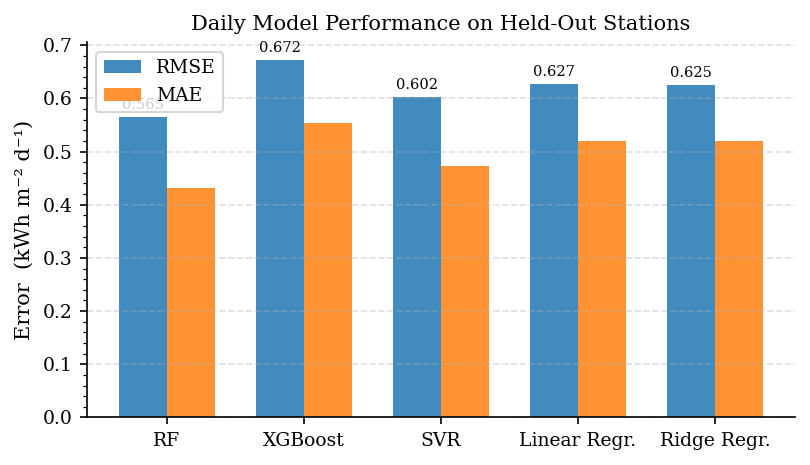

Figure saved → figures/fig_table3_model_comparison.png


In [15]:
# ── Figure: Table III bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.2))

model_names = list(table3_df.index)
x = np.arange(len(model_names))
width = 0.35

bars_rmse = ax.bar(x - width/2, table3_df["RMSE"], width,
                   label="RMSE", color="#1f77b4", alpha=0.85)
bars_mae  = ax.bar(x + width/2, table3_df["MAE"],  width,
                   label="MAE",  color="#ff7f0e", alpha=0.85)

ax.set_ylabel("Error  (kWh m⁻² d⁻¹)")
ax.set_title("Daily Model Performance on Held-Out Stations")
ax.set_xticks(x)
ax.set_xticklabels(
    ["RF", "XGBoost", "SVR", "Linear Regr.", "Ridge Regr."],
    fontsize=9
)
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.4)

# annotate RMSE values on bars
for bar in bars_rmse:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "fig_table3_model_comparison.png")
plt.show()
print(f"Figure saved → {FIGURE_DIR}/fig_table3_model_comparison.png")


## § 5 — Final Random Forest Model

The Random Forest is selected as the final model based on its superior RMSE and
inherent robustness to overfitting (paper Section III). It is retrained here via
`Trainer.train()`, which persists the model bundle to disk and (optionally) logs
metrics to Weights & Biases. The bundle is used by § 6 onwards.


In [16]:
trainer = Trainer(TrainerConfig(
    wandb_project = WANDB_PROJECT if LOG_TO_WANDB else None,
    wandb_entity  = WANDB_ENTITY,
    wandb_tags    = WANDB_TAGS,
    baseline_columns = ("sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"),
))

bundle = trainer.train(
    processed    = processed,
    params       = RandomForestParams(
        n_estimators     = RF_N_ESTIMATORS,
        min_samples_leaf = RF_MIN_SAMPLES_LEAF,
        random_state     = RF_RANDOM_STATE,
    ),
    splitter     = splitter,
    holdout_label = f"sites_A_B::{','.join(HOLDOUT_STATIONS)}",
    bundle_dest  = BUNDLE_DEST,
)

v = bundle.metadata.val_metrics
print("Random Forest — Holdout Performance (daily, kWh m⁻² d⁻¹)")
print(f"  RMSE : {v.rmse:.3f}")
print(f"  MAE  : {v.mae:.3f}")
print(f"  R²   : {v.r2:.3f}")
print(f"Bundle persisted → {BUNDLE_DEST}")


Random Forest — Holdout Performance (daily, kWh m⁻² d⁻¹)
  RMSE : 0.568
  MAE  : 0.448
  R²   : 0.810
Bundle persisted → saved_models/rf_bundle


## § 6 — Independent Ugandan Validation (Paper Table IV)

Validates the trained RF model against the independent network of 54 Ugandan stations
compiled by Katongole et al. (2023). As in the paper:

1. Daily predictions are generated for all 54 stations for every day in **2021**.
2. Predictions are arithmetically averaged within each calendar month.
3. Monthly model predictions are compared against monthly ground measurements
   and against NASA CERES and CAMS satellite products.

A sensor-calibration ratio is applied to account for the systematic offset between
the MEMD/CrossBoundary pyranometers used in training and the TAHMO ATMOS 41 sensors
used by the Katongole network.


In [25]:
from susse.warehouse_ops.io.repositories import SatelliteRepository
import pygeohash
import auxscripts
from datetime import date

VAL_START = date(VALIDATION_YEAR, 1, 1)
VAL_END = date(VALIDATION_YEAR, 12, 31)

katongole = pd.read_csv(KATONGOLE_CSV)
katongole["geohash5"] = [
    pygeohash.encode(lat, lon, precision=5)
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]

# Train-fold geohashes and NASA 0.5° cells — overlap flags for §6 metrics.
train_fold = processed.df.loc[train_idx]
training_geohashes = set(train_fold["geohash5"].unique())
training_nasa_cells = {
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(train_fold["lat"], train_fold["lon"])
}
katongole["nasa_cell"] = [
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]
katongole["seen_in_training_geohash5"] = katongole["geohash5"].isin(training_geohashes)
katongole["seen_in_training_nasa_cell"] = katongole["nasa_cell"].isin(training_nasa_cells)
print(
    f"{len(katongole)} Katongole stations:  "
    f"{int(katongole['seen_in_training_geohash5'].sum())} share a geohash5 "
    f"with a training station,  "
    f"{int(katongole['seen_in_training_nasa_cell'].sum())} share a NASA 0.5° cell."
)

# Hard-fail if any station lacks coverage. Pass allow_partial=True for
# inspecting intermediate state while the A12 ingest is still running.
auxscripts.assert_katongole_coverage(
    bq, tables, katongole, VAL_START, VAL_END,
)
inference_df = auxscripts.build_katongole_inference_frame(
    bq=bq, tables=tables, sat_repo=SatelliteRepository(bq=bq),
    katongole=katongole, selection=selection,
    nasa_aux_ids=NASA_AUX_IDS, cams_aux_ids=CAMS_AUX_IDS,
    val_start=VAL_START, val_end=VAL_END,
)
auxscripts.assert_inference_complete(katongole, inference_df)

56 Katongole stations:  3 share a geohash5 with a training station,  4 share a NASA 0.5° cell.


In [26]:
# Apply the trained bundle's feature spec to the inference frame and
# predict. Reloading from disk mirrors what the portal does.
from susse.training import load_bundle

restored = load_bundle(
    BUNDLE_DEST, providers={"altitude": PvlibElevationProvider()},
)
inference_dataset = TrainingDataset(
    df=inference_df.assign(y_ghi_kwh_m2_day=np.nan),
    manifest=manifest,
)
inference_spec_for_predict = FeatureSpec(
    target_column=restored.feature_spec.target_column,
    feature_columns=restored.feature_spec.feature_columns,
    cleaners=(),
    derived_features=restored.feature_spec.derived_features,
    id_columns=restored.feature_spec.id_columns,
    dropna_target=False, dropna_features=False,
)
inference_processed = Preprocessor(inference_spec_for_predict).apply(inference_dataset)
inference_processed.df["y_pred_kwh_m2_day"] = restored.regressor.predict(
    inference_processed.X()
)
print(
    f"Predictions: {len(inference_processed.df):,} daily values across "
    f"{inference_processed.df['location'].nunique()} stations"
)

Predictions: 20,440 daily values across 56 stations


In [27]:
# Aggregate daily predictions to a monthly climatology per station,
# then join with the Katongole reference values for scoring.
monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])["y_pred_kwh_m2_day"]
    .mean().reset_index()
    .rename(columns={"y_pred_kwh_m2_day": "monthly_pred"})
)
sat_monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])[
        ["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]
    ].mean().reset_index()
)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
katongole_long = katongole.melt(
    id_vars=["location", "latitude", "longitude", "altitude",
             "geohash5", "seen_in_training_geohash5", "seen_in_training_nasa_cell"],
    value_vars=month_names,
    var_name="month_name", value_name="monthly_obs",
)
katongole_long["month"] = katongole_long["month_name"].apply(
    lambda m: month_names.index(m) + 1
)
comparison = (
    monthly
    .merge(katongole_long, on=["location", "month"], how="inner")
    .merge(sat_monthly,    on=["location", "month"], how="left")
)
table_iv_raw = pd.concat([
    auxscripts.score_table_iv(comparison, label=f"all {comparison['location'].nunique()} stations"),
    auxscripts.score_table_iv(
        comparison[~comparison["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
    ),
])
print("=== Paper Table IV equivalent (uncalibrated) ===")
print(table_iv_raw.to_string(index=False))

=== Paper Table IV equivalent (uncalibrated) ===
                              split      model   n   RMSE  nRMSE_%    MAE  nMAE_%    MBE      R²    IOA
                    all 56 stations         RF 672 0.8360  19.5900 0.6980 16.3500 0.6590 -0.9470 0.5660
                    all 56 stations NASA CERES 672 1.2430  29.1300 1.1290 26.4400 1.1160 -3.3060 0.4620
                    all 56 stations       CAMS 672 1.3070  30.6300 1.2000 28.1200 1.1930 -3.7620 0.4640
excluding training-geohash overlaps         RF 636 0.8170  19.2000 0.6810 16.0200 0.6410 -0.9960 0.5490
excluding training-geohash overlaps NASA CERES 636 1.2260  28.8100 1.1160 26.2200 1.1020 -3.4960 0.4510
excluding training-geohash overlaps       CAMS 636 1.2810  30.1200 1.1820 27.7900 1.1740 -3.9130 0.4580


## 6.3 — Calibration discrepancy at Makerere

§6's uncalibrated metrics over-predict Katongole by ~0.85 kWh/m²/day
on average. The cause is a **cross-network sensor offset** — our training
data uses MEMD/CrossBoundary research-grade pyranometers (annually
recalibrated), while Katongole uses the TAHMO ATMOS 41 combination
sensor (a mid-grade weather-station instrument with ±5% factory tolerance
and no regular calibration). Our `kampala` station and Katongole's
`Makerere S` station sit at *literally identical coordinates*
`(0.333542°, 32.56863°)`. Comparing the two over the same 2017–2022
window measures the network offset directly.

Annual mean ratio (kampala / Makerere S): 1.180


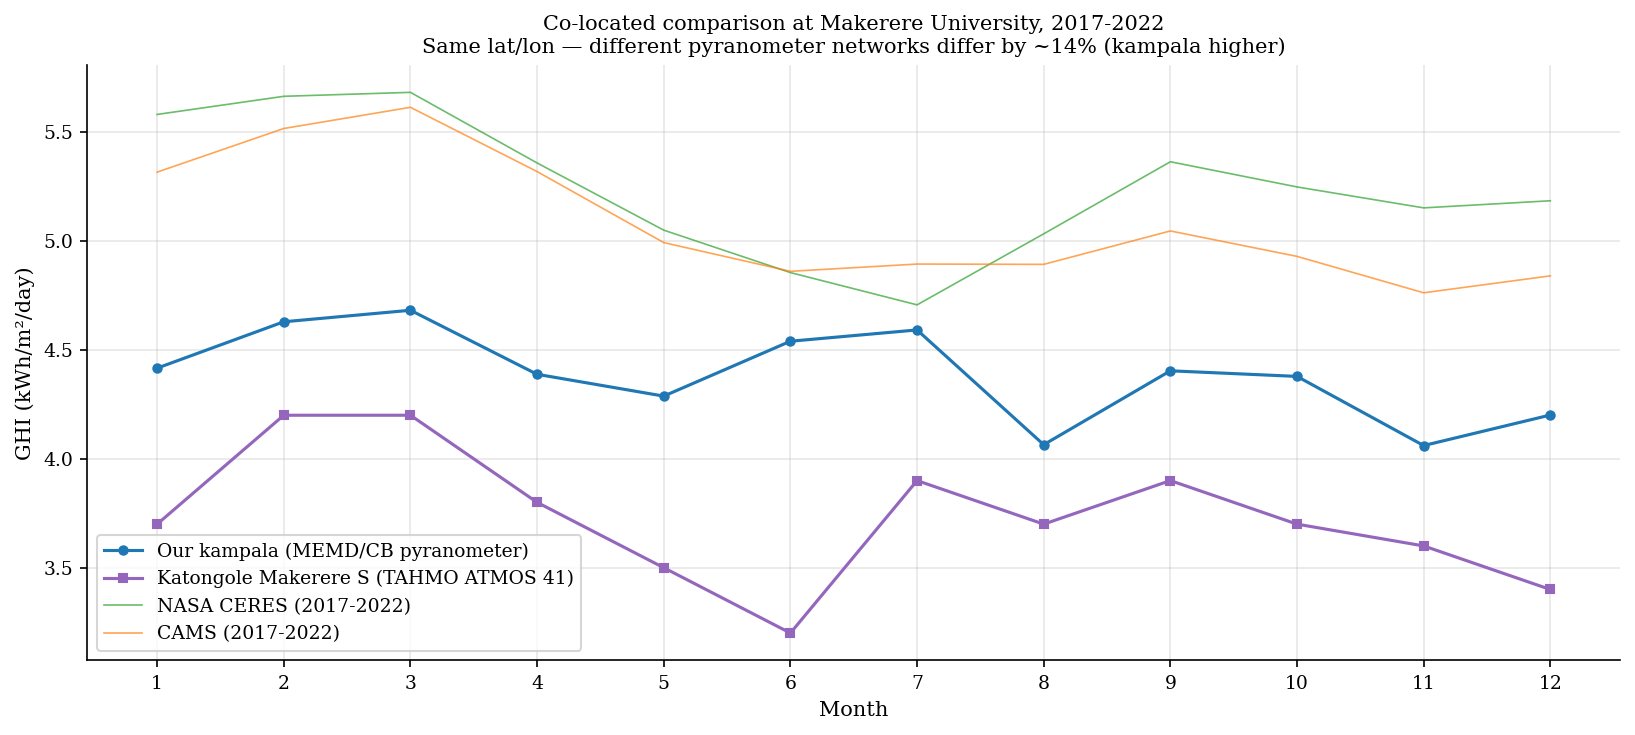

In [30]:
# Pull our kampala monthly climatology over 2017-2022.
kampala_monthly = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS kampala_mean,
       COUNT(*) AS n_days
FROM `{tables.ground_measurements}`
WHERE location = "kampala" AND qc_level = "pass"
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month ORDER BY month
""")
makerere_row = katongole[katongole["location"] == "Makerere S"]
makerere_long = pd.DataFrame({
    "month": list(range(1, 13)),
    "makerere_mean": [float(makerere_row[m].iloc[0]) for m in month_names],
})
kampala_gh = pygeohash.encode(0.333542, 32.56863, 5)
sat_monthly_2017_22 = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month, source,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS mean_ghi
FROM `{tables.irradiance_daily}`
WHERE geohash5 = "{kampala_gh}"
  AND source IN ("NASA", "CAMS")
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month, source ORDER BY month, source
""").pivot(index="month", columns="source", values="mean_ghi").reset_index()

calibration_df = (
    kampala_monthly.merge(makerere_long, on="month")
    .merge(sat_monthly_2017_22, on="month")
)
calibration_df["ratio"] = (
    calibration_df["kampala_mean"] / calibration_df["makerere_mean"]
)
annual_ratio = float(calibration_df["ratio"].mean())
print(f"Annual mean ratio (kampala / Makerere S): {annual_ratio:.3f}")
auxscripts.plot_calibration_discrepancy(calibration_df)

## 6.4 — Calibrated Table IV

A single annual ratio (mean of the 12 monthly ratios — ~1.18) rescales
TAHMO Katongole values onto the MEMD/CB scale before scoring. Per-month
ratios would overfit on one co-located pair × 7 years (June's
~1.42 over-corrects Ndejje to 7.8 kWh/m²/day, which is non-physical).
A monotonic linear rescaling shifts RF and satellite RMSEs together —
the *relative* improvement claim is preserved.

In [32]:
comparison_calibrated = comparison.copy()
comparison_calibrated["monthly_obs_calibrated"] = (
    comparison_calibrated["monthly_obs"] * annual_ratio
)
table_iv_calibrated = pd.concat([
    auxscripts.score_table_iv(
        comparison_calibrated,
        label=f"all {comparison_calibrated['location'].nunique()} stations",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_nasa_cell"]],
        label="excluding training-NASA-cell overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
])
print("=== Paper Table IV equivalent — calibration-corrected ===")
print(table_iv_calibrated.to_string(index=False))

=== Paper Table IV equivalent — calibration-corrected ===
                                split           model   n   RMSE  nRMSE_%    MAE  nMAE_%     MBE      R²    IOA
                      all 56 stations RF (calibrated) 672 0.6130  12.1800 0.4510  8.9400 -0.1100  0.2470 0.6380
                      all 56 stations      NASA CERES 672 0.7220  14.3300 0.5370 10.6600  0.3470 -0.0430 0.6080
                      all 56 stations            CAMS 672 0.7440  14.7600 0.5590 11.0900  0.4240 -0.1060 0.6500
  excluding training-geohash overlaps RF (calibrated) 636 0.6080  12.1100 0.4480  8.9300 -0.1260  0.2060 0.6040
  excluding training-geohash overlaps      NASA CERES 636 0.7050  14.0400 0.5280 10.5200  0.3360 -0.0670 0.5940
  excluding training-geohash overlaps            CAMS 636 0.7140  14.2300 0.5470 10.8900  0.4080 -0.0960 0.6490
excluding training-NASA-cell overlaps RF (calibrated) 624 0.6060  12.0800 0.4460  8.8800 -0.1330  0.2100 0.6040
excluding training-NASA-cell overlaps      NAS

### Residual diagnostics

Three diagnostic views on the §6.4 metrics: covariate-shift KDEs
(training vs Katongole feature distributions), a predicted-vs-observed
scatter, and per-station MBE.

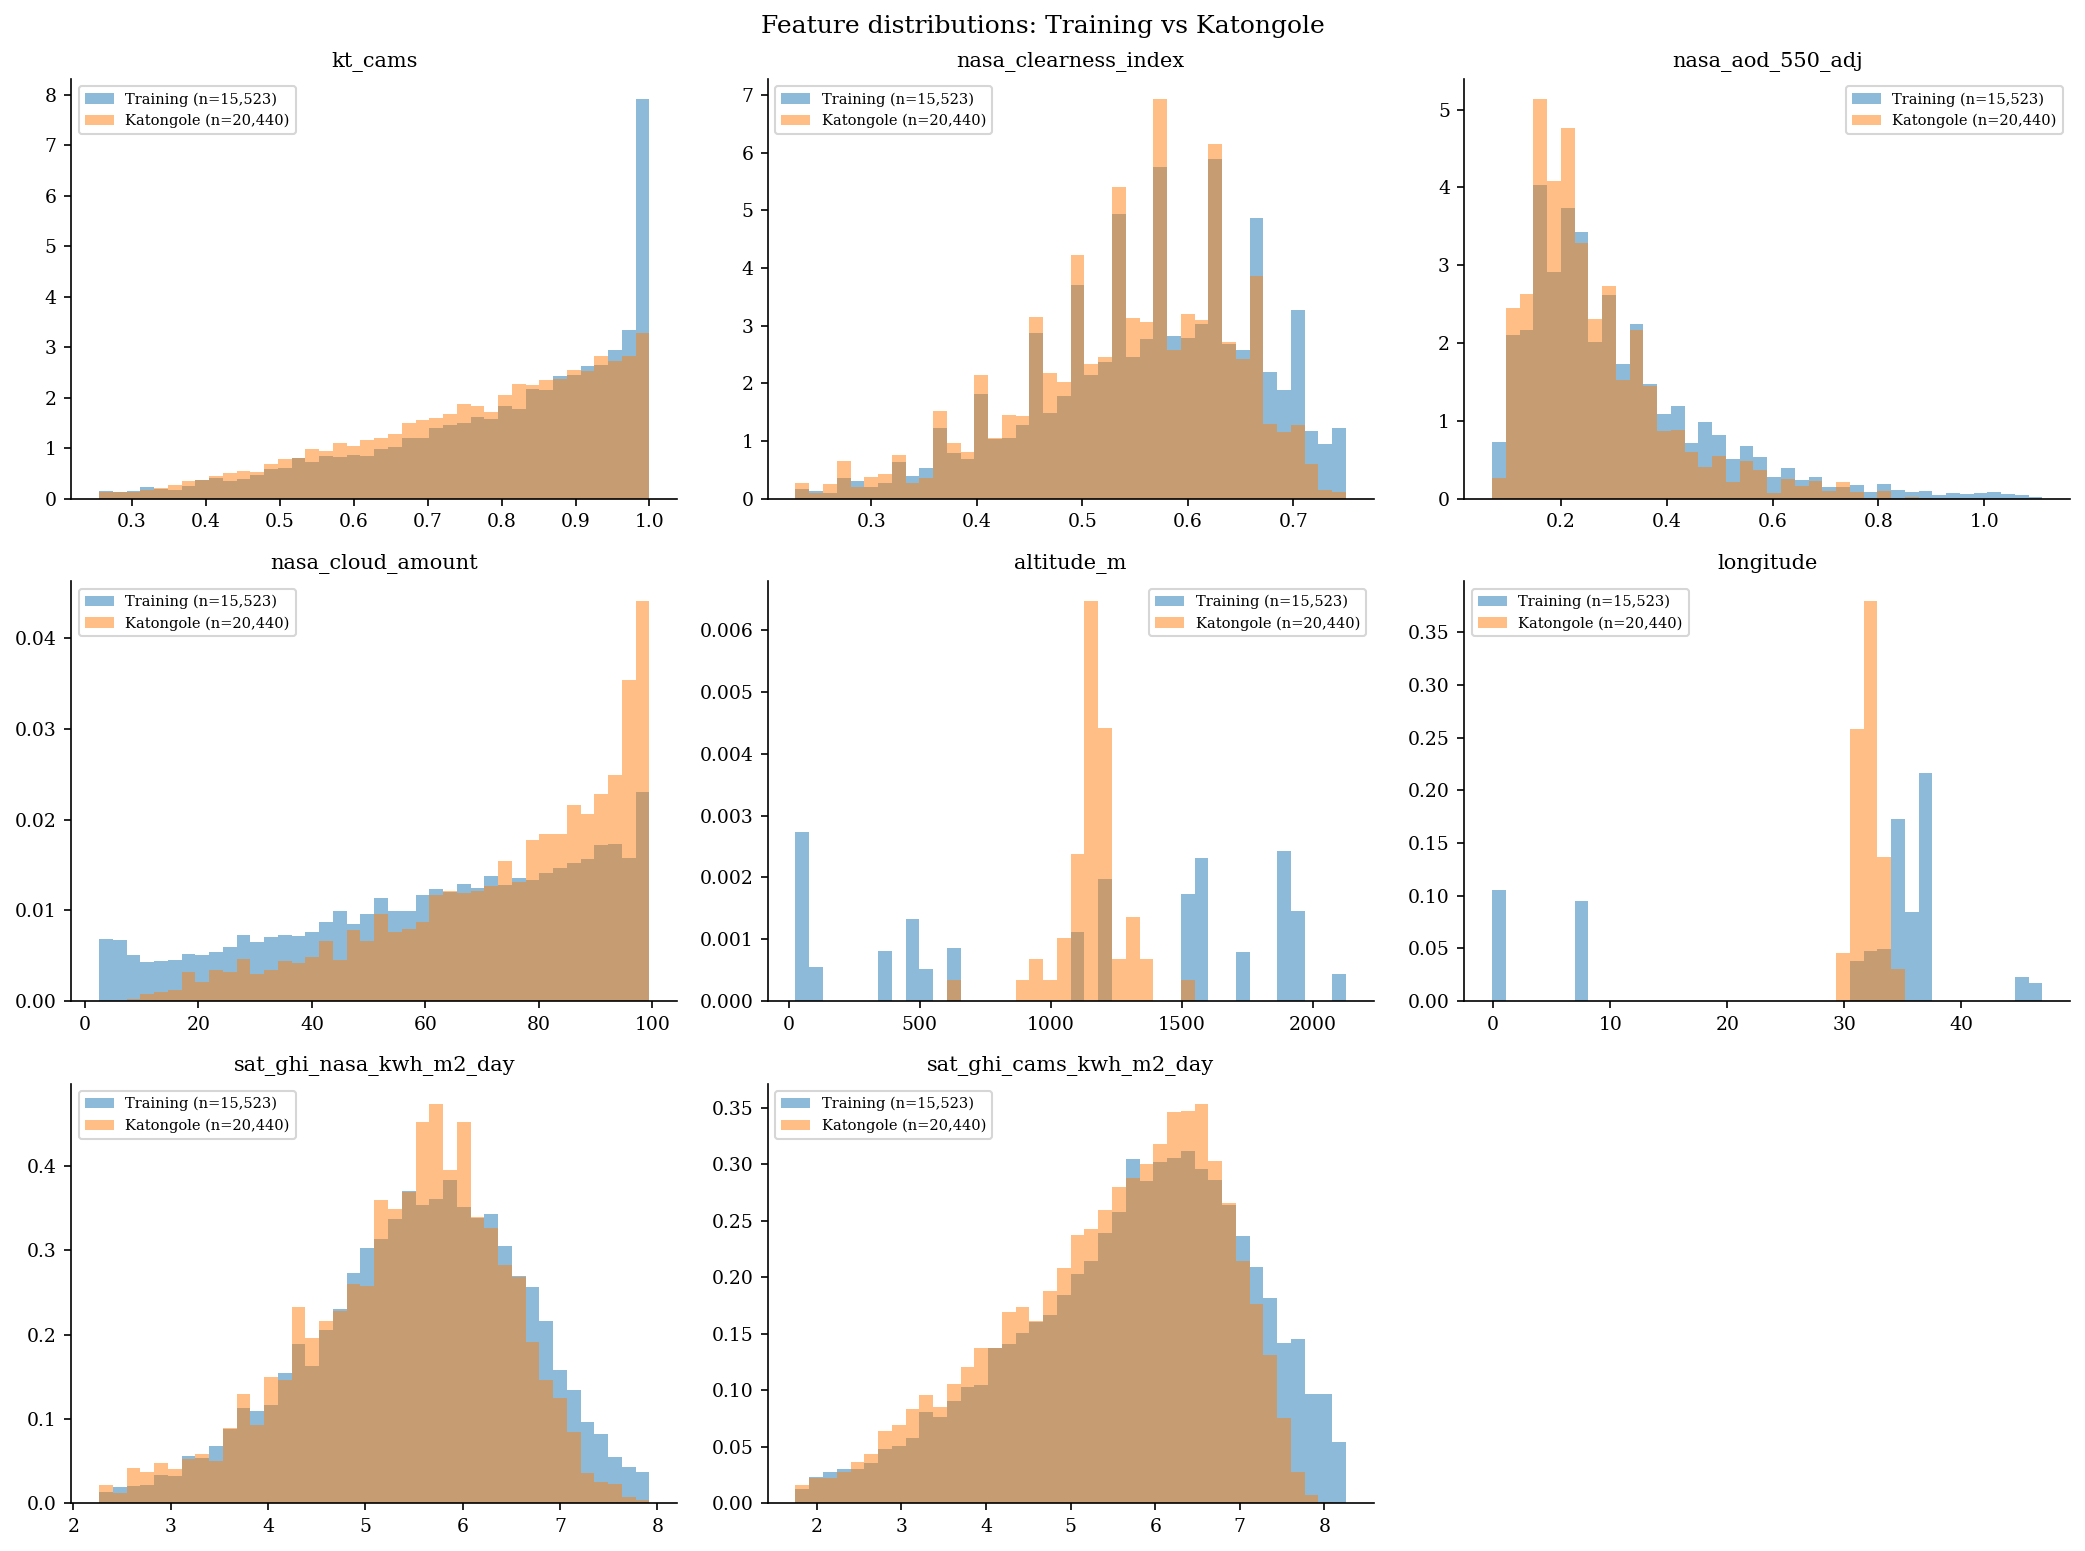

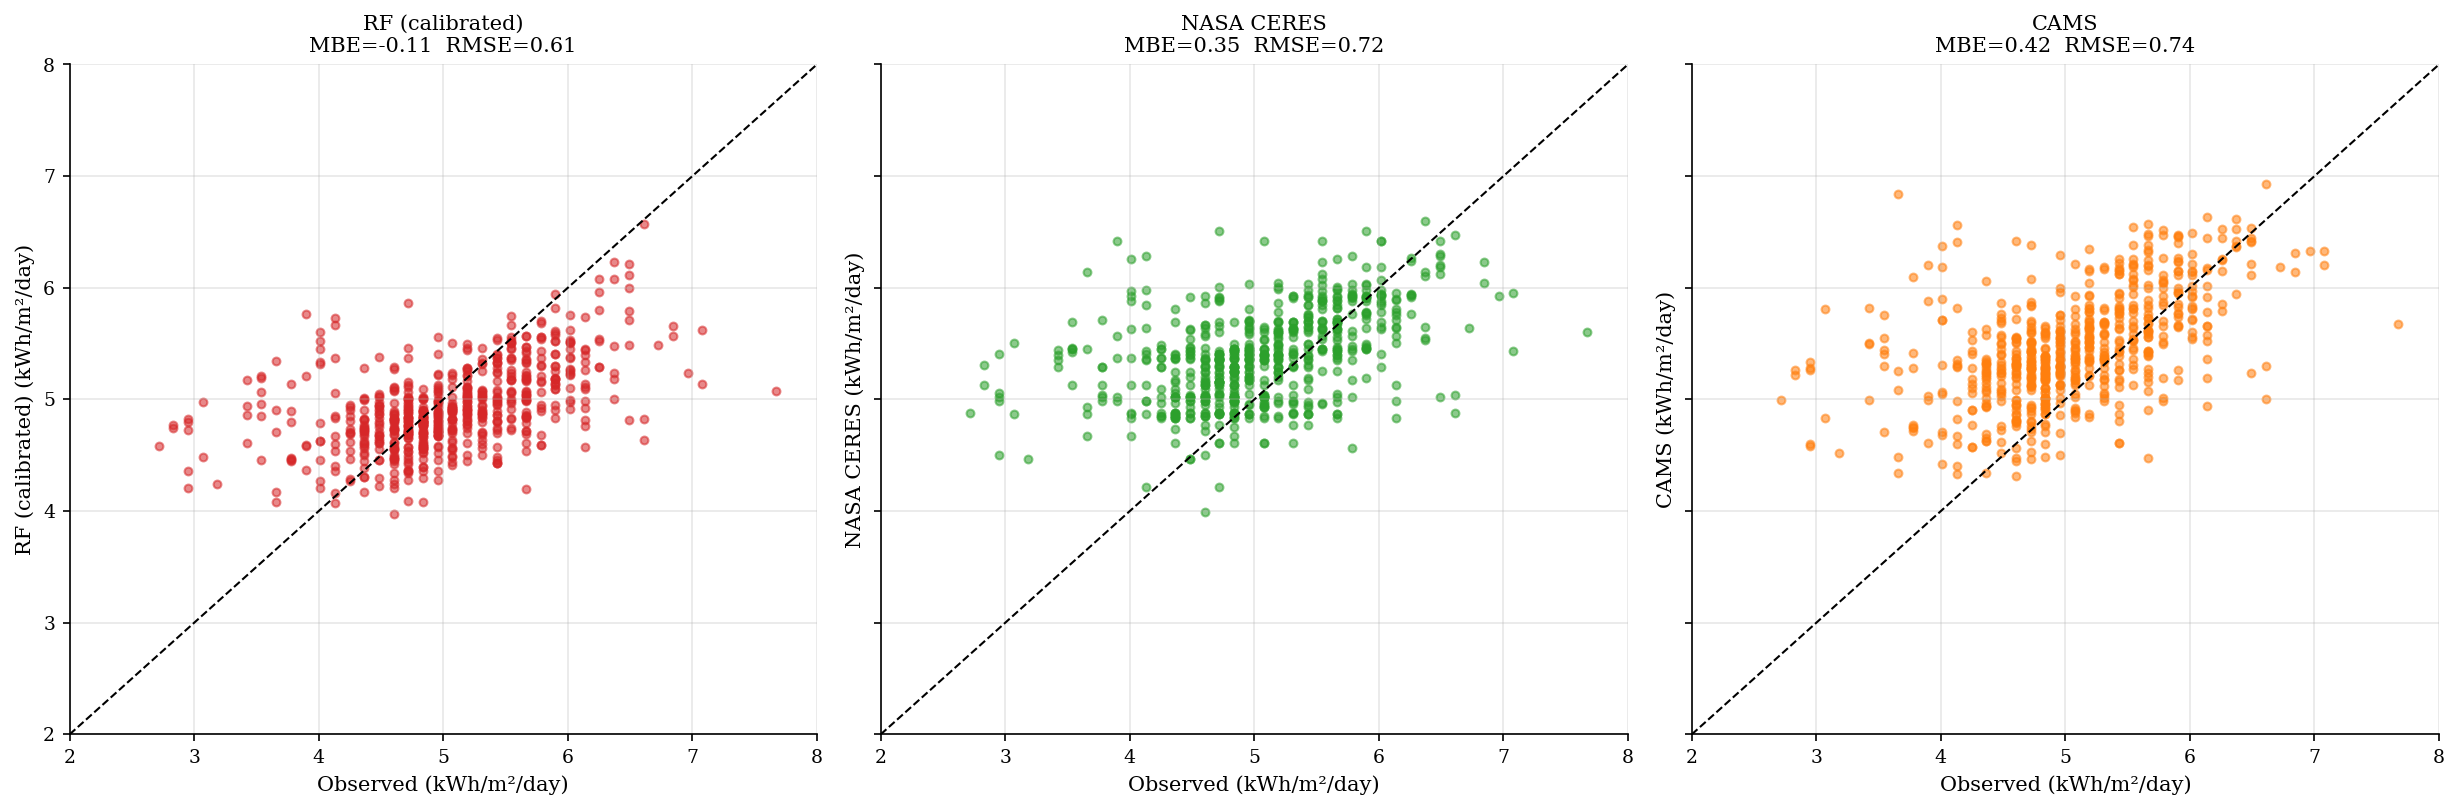

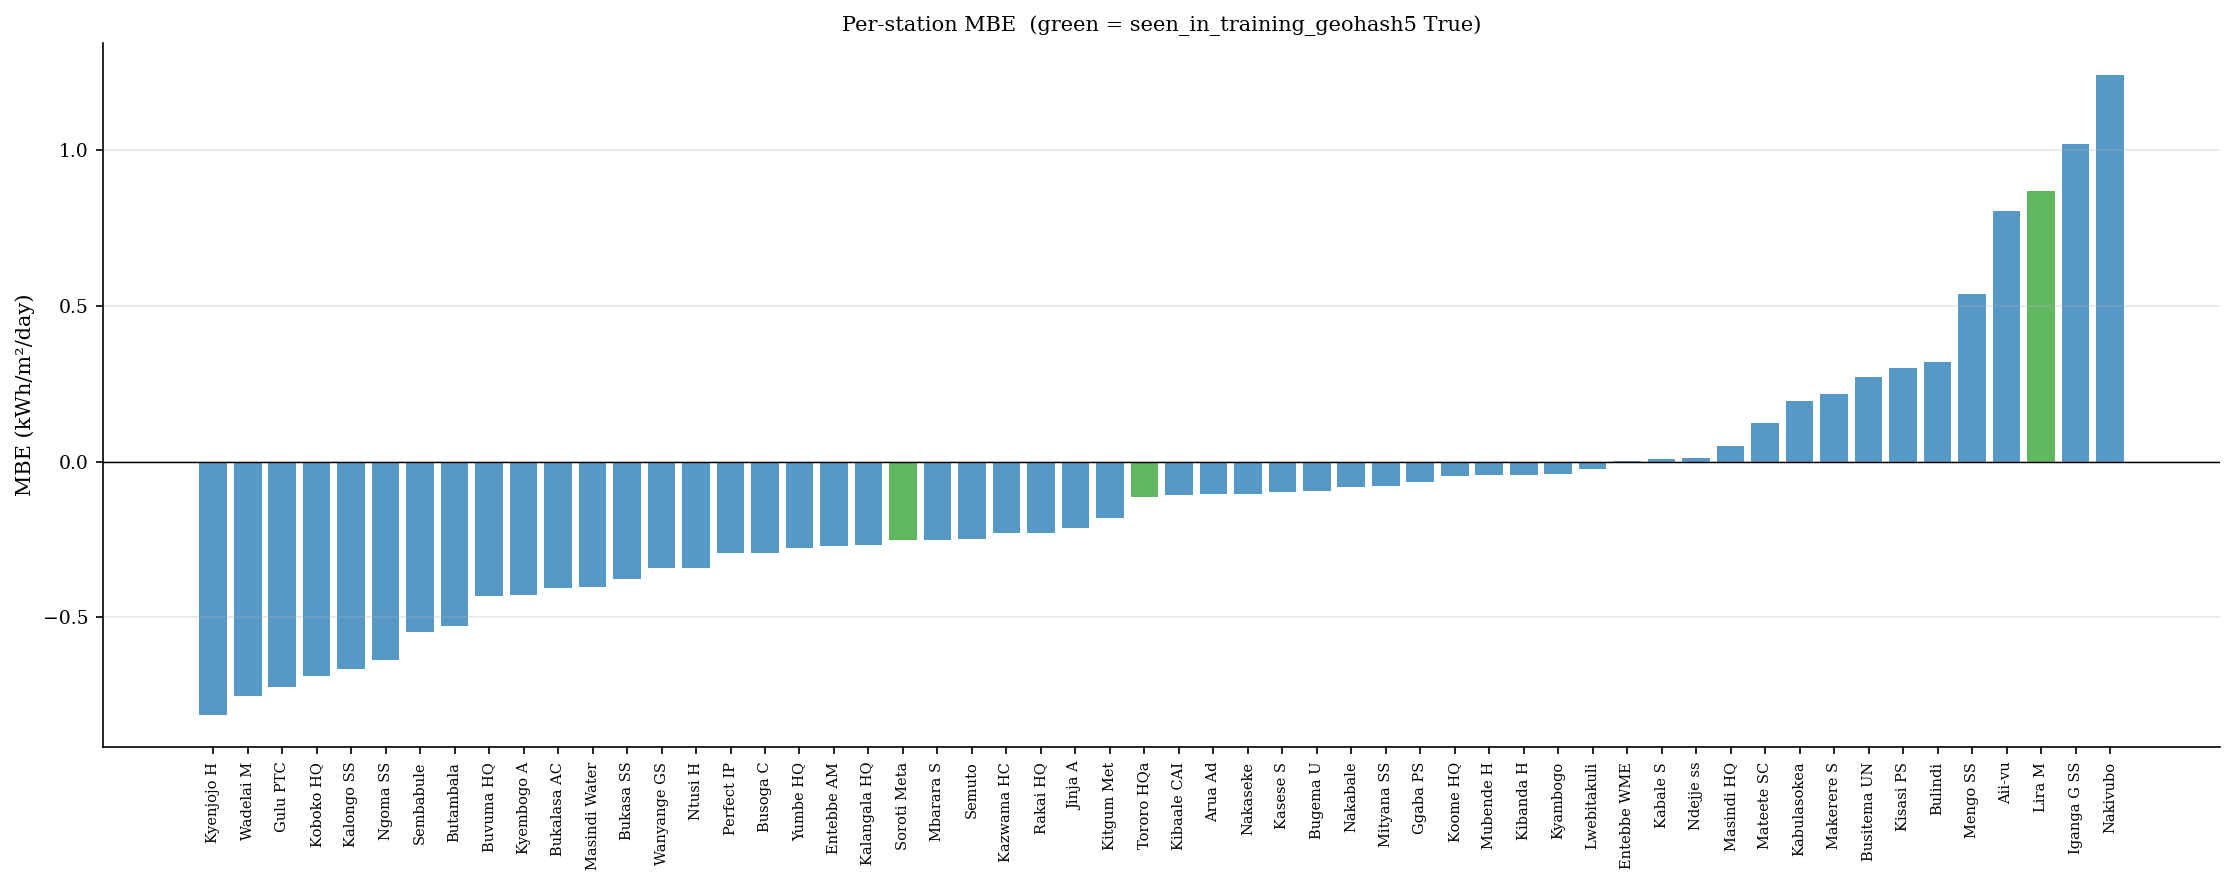

Worst (highest MBE):
               MBE  _highlight
location                      
Mengo SS    0.5390       False
Aii-vu      0.8050       False
Lira M      0.8710        True
Iganga G SS 1.0220       False
Nakivubo    1.2410       False

Best (lowest MBE):
               MBE  _highlight
location                      
Kyenjojo H -0.8140       False
Wadelai M  -0.7510       False
Gulu PTC   -0.7250       False
Koboko HQ  -0.6890       False
Kalongo SS -0.6660       False


In [34]:
from susse.evaluation import MeanBiasError
from susse.evaluation.plots import (
    plot_covariate_shift_kde,
    plot_per_station_metric,
    plot_predicted_vs_observed_panels,
)

plot_covariate_shift_kde(
    processed.df, inference_processed.df,
    features=[
        "kt_cams", "nasa_clearness_index", "nasa_aod_550_adj",
        "nasa_cloud_amount", "altitude_m", "longitude",
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
    ],
    train_label="Training", val_label="Katongole",
)
plot_predicted_vs_observed_panels(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predictions={
        "RF (calibrated)": "monthly_pred",
        "NASA CERES":      "sat_ghi_nasa_kwh_m2_day",
        "CAMS":            "sat_ghi_cams_kwh_m2_day",
    },
)
plot_per_station_metric(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predicted_column="monthly_pred",
    metric=MeanBiasError(),
    highlight_column="seen_in_training_geohash5",
)

## § 7 — Regional Analysis (Paper Figure 3)

Monthly mean daily GHI for 16 representative stations (4 per region) across the
four Ugandan climatic zones. Reproduces Figure 3 of the paper.


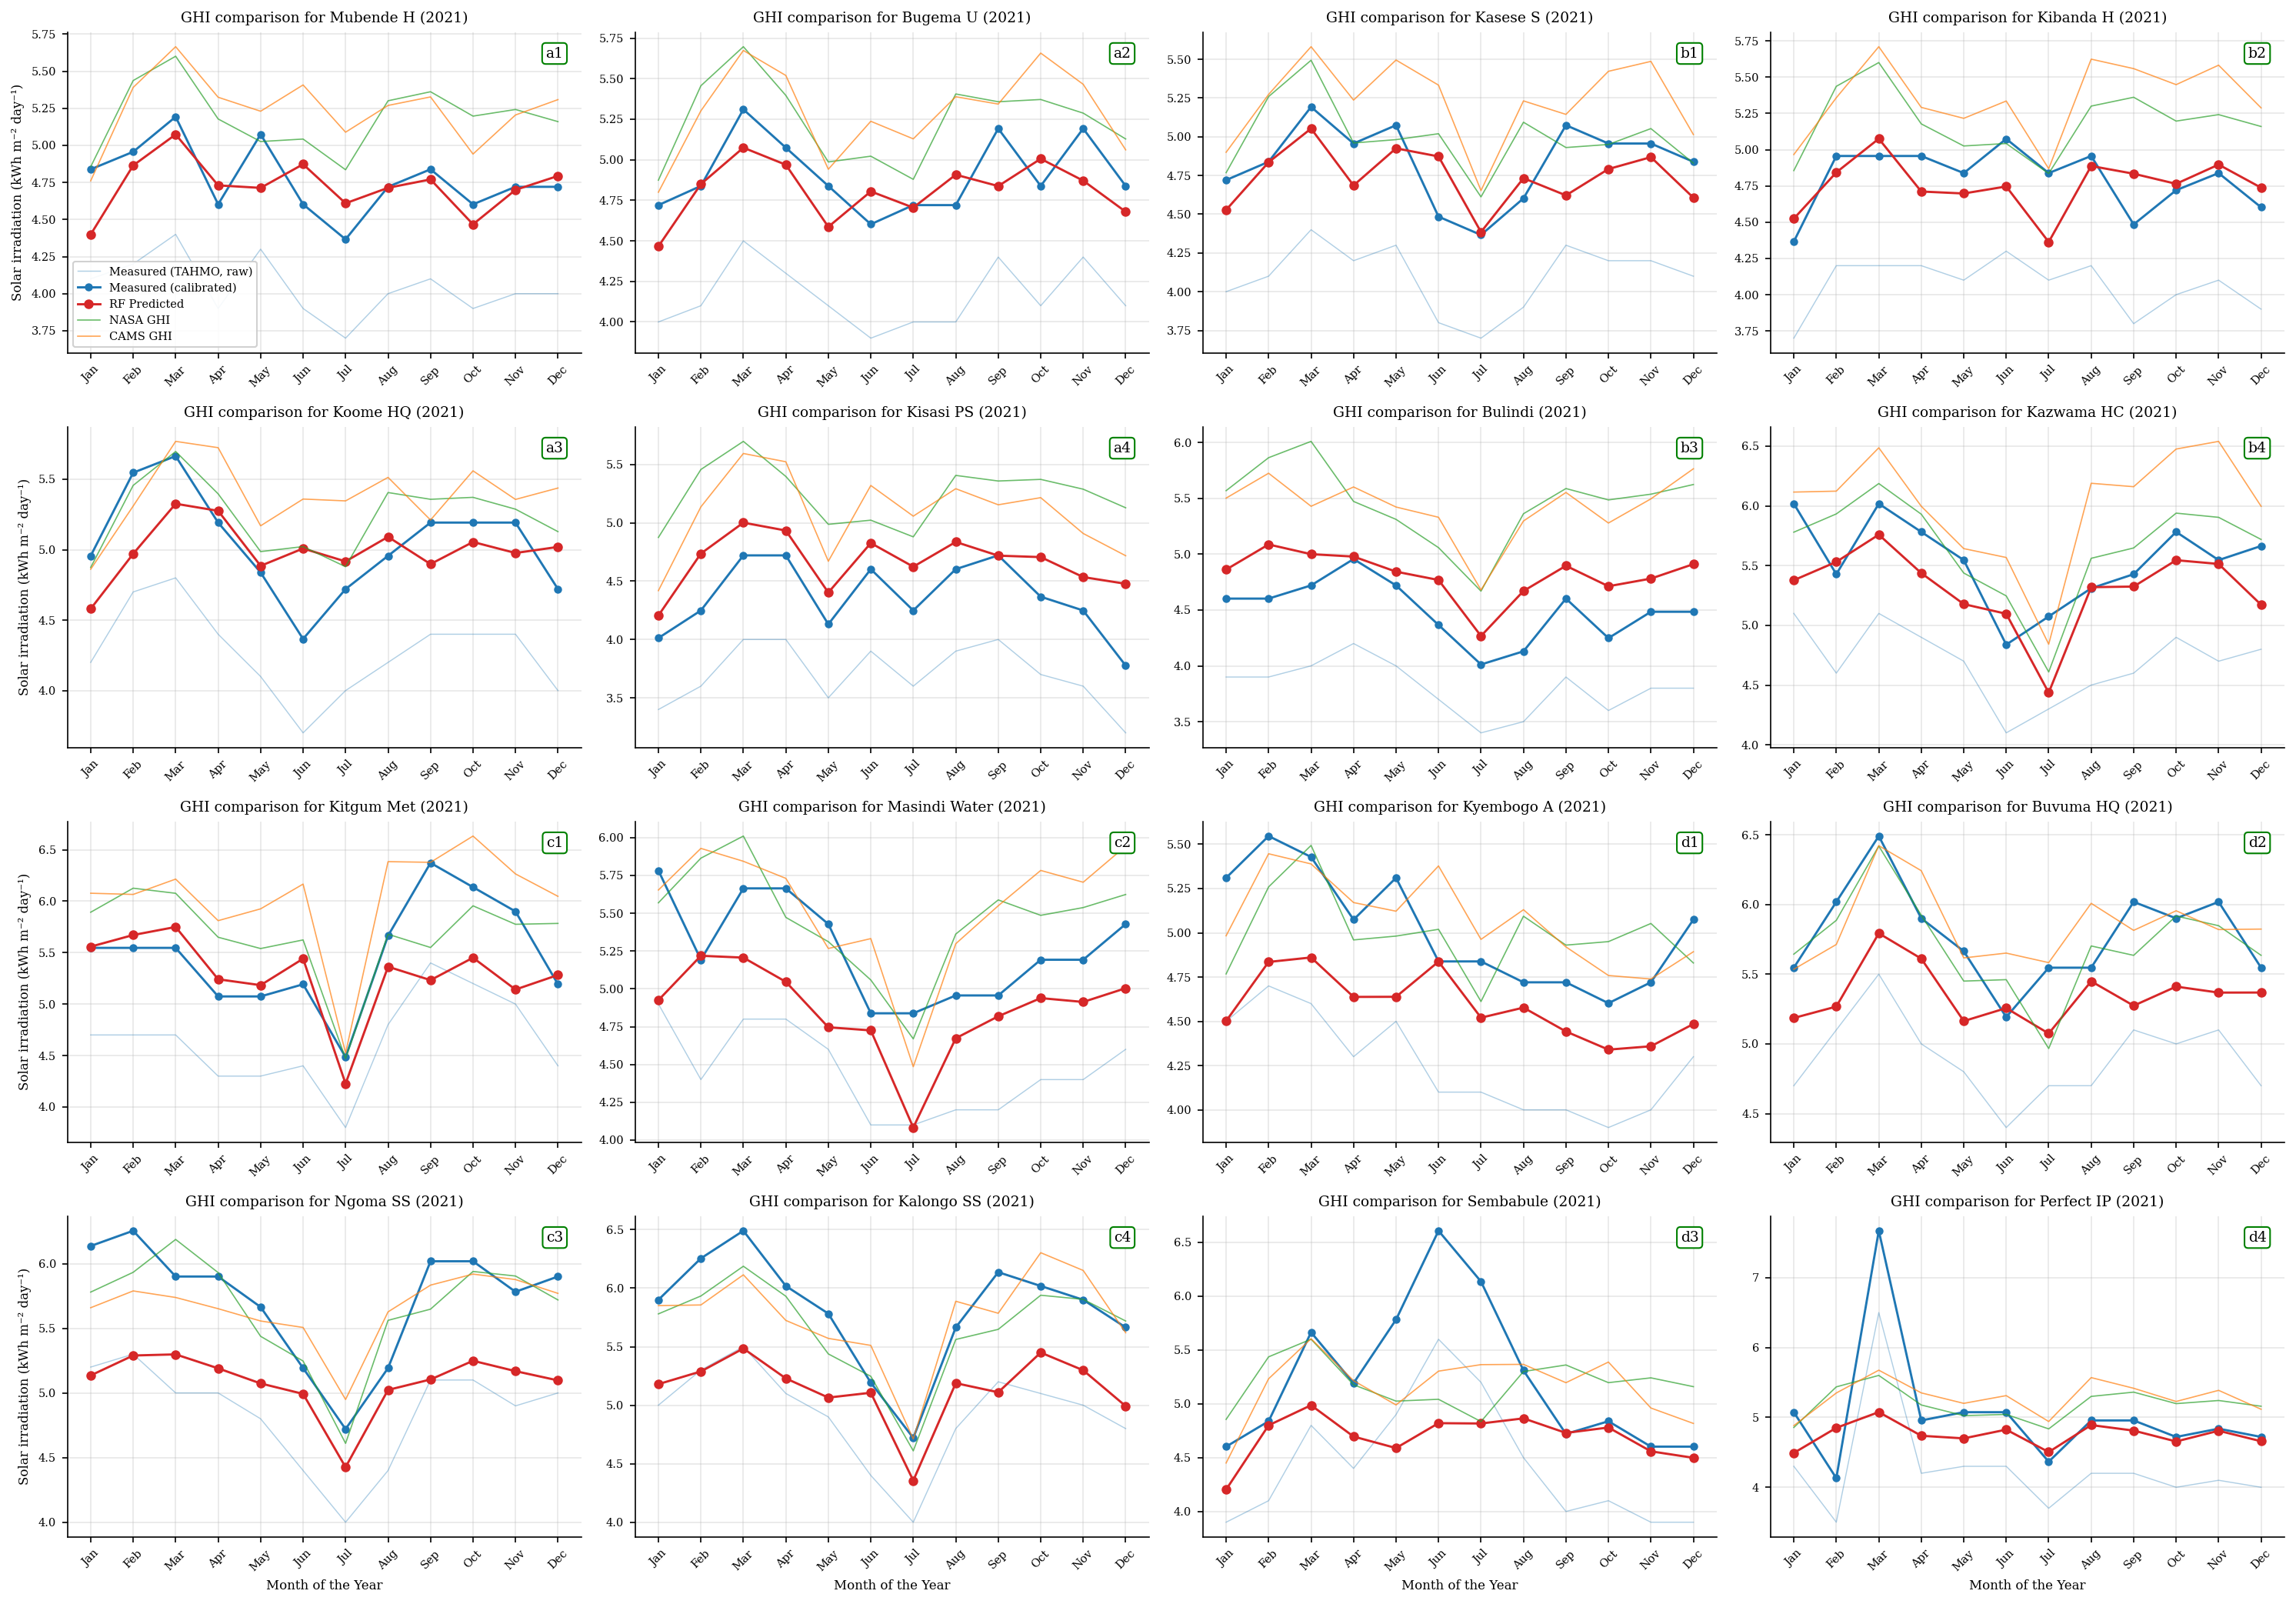

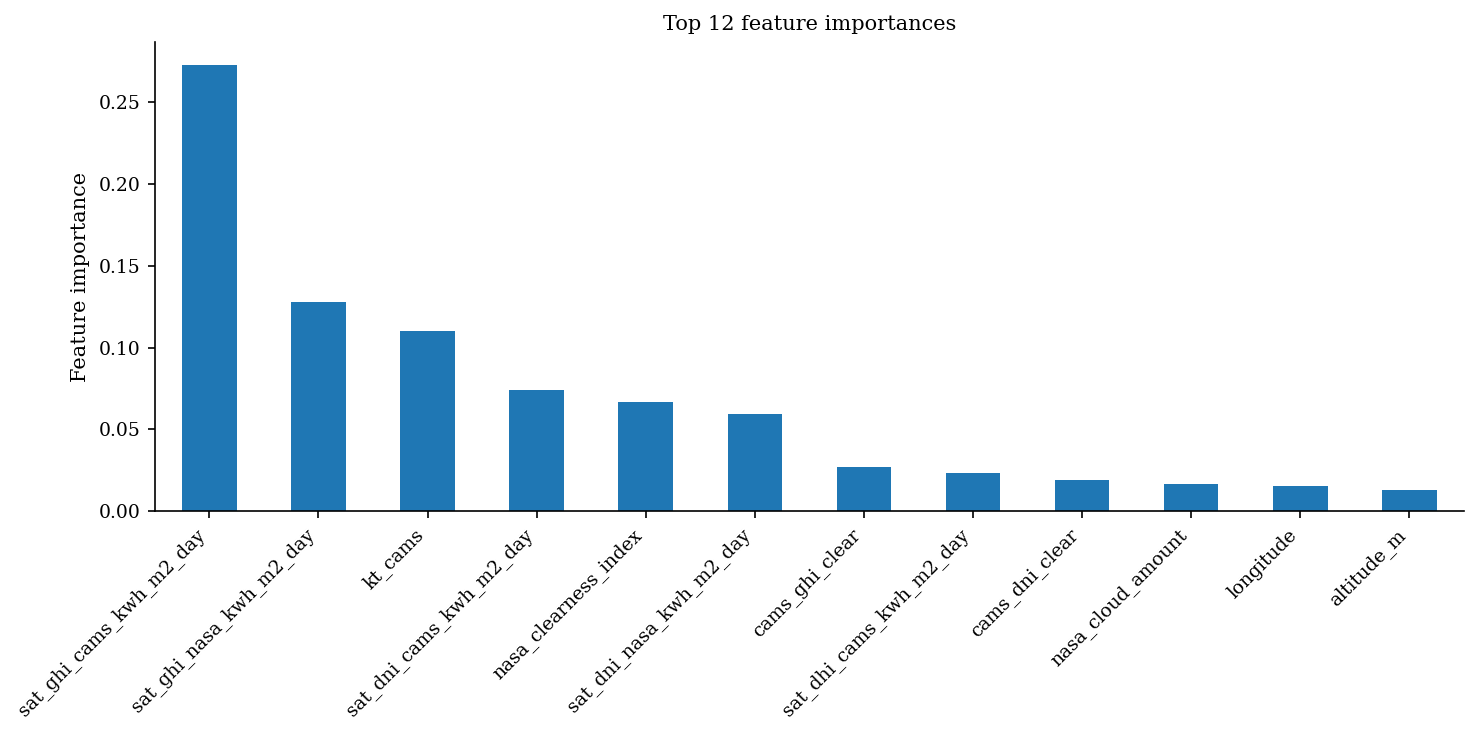

sat_ghi_cams_kwh_m2_day   0.2730
sat_ghi_nasa_kwh_m2_day   0.1280
kt_cams                   0.1101
sat_dni_cams_kwh_m2_day   0.0742
nasa_clearness_index      0.0667
sat_dni_nasa_kwh_m2_day   0.0594
cams_ghi_clear            0.0267
sat_dhi_cams_kwh_m2_day   0.0236
cams_dni_clear            0.0189
nasa_cloud_amount         0.0168
longitude                 0.0155
altitude_m                0.0130
dtype: float64

In [37]:
from susse.evaluation.plots import plot_feature_importances_top_n

auxscripts.plot_figure_2_grid(
    comparison_calibrated,
    validation_label=f"{VALIDATION_YEAR}",
)

## § 8 — Feature Importance (Paper Figure 4)

Normalised feature importances extracted from the trained Random Forest.
Reproduces Figure 4 of the paper. As expected, `ghi_cams` dominates, with
`ALLSKY_SFC_SW_DWN` (NASA CERES GHI) second.


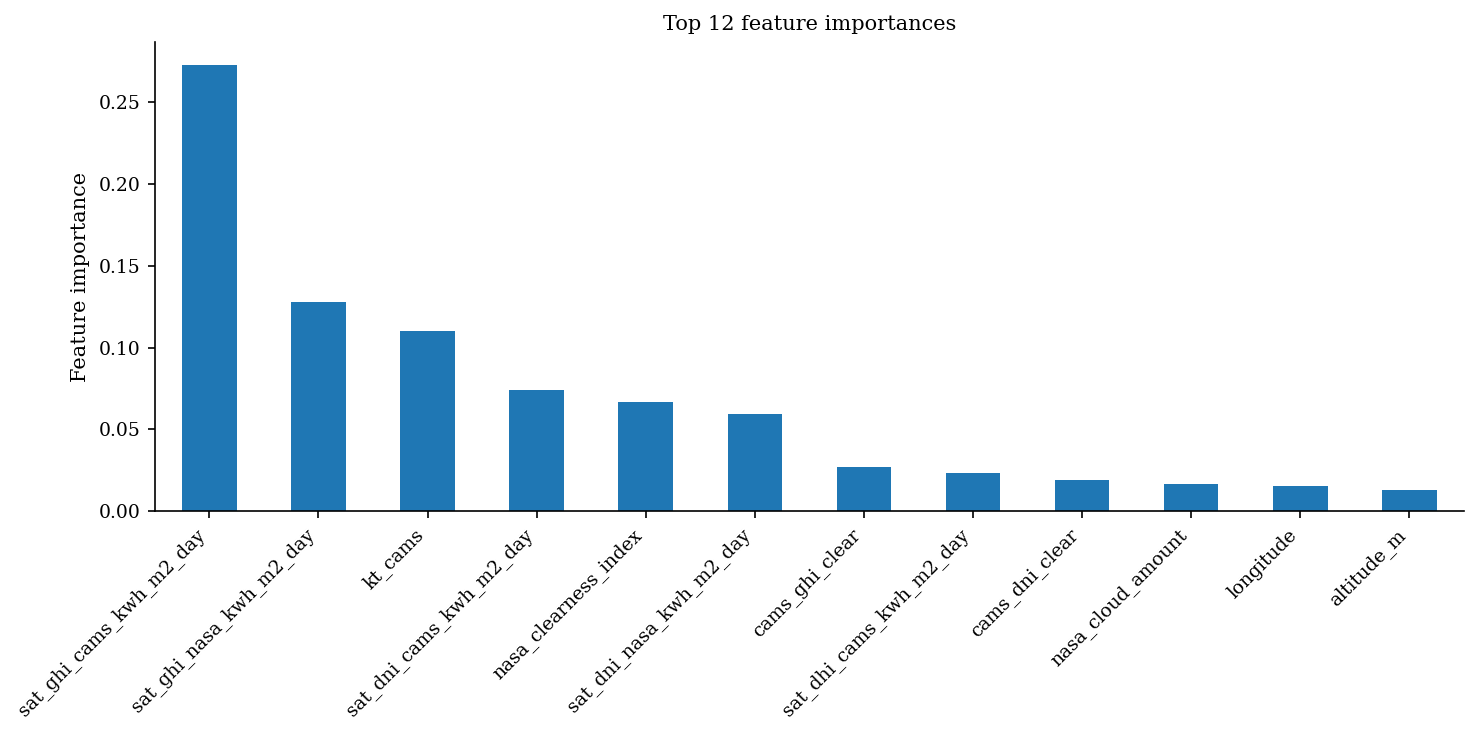

sat_ghi_cams_kwh_m2_day   0.2730
sat_ghi_nasa_kwh_m2_day   0.1280
kt_cams                   0.1101
sat_dni_cams_kwh_m2_day   0.0742
nasa_clearness_index      0.0667
sat_dni_nasa_kwh_m2_day   0.0594
cams_ghi_clear            0.0267
sat_dhi_cams_kwh_m2_day   0.0236
cams_dni_clear            0.0189
nasa_cloud_amount         0.0168
longitude                 0.0155
altitude_m                0.0130
dtype: float64

In [40]:

top_importances = plot_feature_importances_top_n(
    bundle, feature_columns=processed.feature_columns, top_n=12,
)
top_importances